# PCA vía Algoritmos Genéticos
**Ximena Quintanar**  
16 de junio de 2026

PCA clásico encuentra direcciones de máxima varianza resolviendo un problema espectral.  
Aquí lo reformulamos como optimización global y lo resolvemos con un algoritmo genético,  
útil cuando hay restricciones no lineales, datos masivos o se quiere robustez ante outliers.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh, norm

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "monospace",
})
np.random.seed(42)


## 1. Datos sintéticos y solución analítica (referencia)

Generamos datos en $\mathbb{R}^2$ con estructura de covarianza conocida.  
La solución exacta viene de los eigenvectores de $S = \frac{1}{n-1}X^\top X$.


Eigenvalores: [4.2095 0.1063]
Varianza explicada por PC1: 97.5%
w analítico = [-0.826  -0.5636]


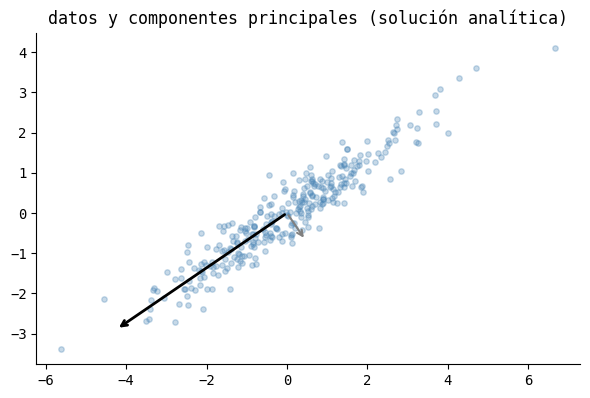

In [2]:
n, p = 300, 2
cov_true = np.array([[3.0, 2.0],
                     [2.0, 1.5]])
L = np.linalg.cholesky(cov_true)
X = (L @ np.random.randn(p, n)).T

S = X.T @ X / (n - 1)

vals, vecs = eigh(S)
idx = np.argsort(vals)[::-1]
vals, vecs = vals[idx], vecs[:, idx]
w_analitico = vecs[:, 0]

print(f"Eigenvalores: {vals.round(4)}")
print(f"Varianza explicada por PC1: {vals[0]/vals.sum():.1%}")
print(f"w analítico = {w_analitico.round(4)}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], alpha=0.3, s=15, color="steelblue")
scale = 2.5
for i, col in enumerate(["k", "gray"]):
    ax.annotate("", xy=vecs[:, i]*scale*vals[i]**0.5,
                xytext=(0,0), arrowprops=dict(arrowstyle="->", color=col, lw=2-i*0.5))
ax.set_aspect("equal")
ax.set_title("datos y componentes principales (solución analítica)")
plt.tight_layout()
plt.show()


## 2. Formulación como optimización global

$$w^* = \arg\max_{\|w\|=1} w^\top S w$$

**Fitness:** $F(w) = w^\top S w$  
**Espacio de búsqueda:** ángulo $\varphi \in [0, 2\pi)$, con $w = (\cos\varphi, \sin\varphi)$.


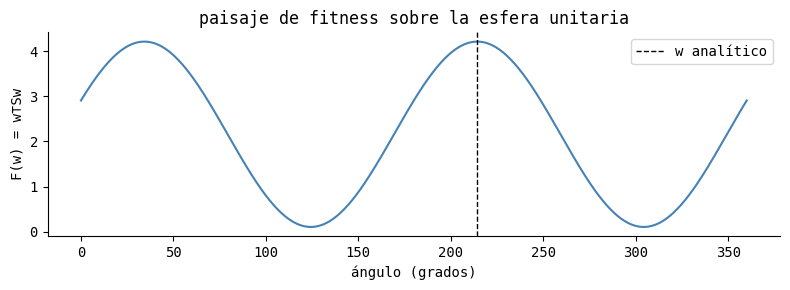

In [3]:
def fitness_l2(w, S_or_X):
    w = w / norm(w)
    if S_or_X.shape == (2, 2):          # recibe S
        return float(w @ S_or_X @ w)
    proj = S_or_X @ w                   # recibe X, forma (n,)
    return float(np.dot(proj, proj))

angulos = np.linspace(0, 2*np.pi, 500)
fs = [fitness_l2(np.array([np.cos(a), np.sin(a)]), S) for a in angulos]
angulo_opt = np.arctan2(w_analitico[1], w_analitico[0]) % (2*np.pi)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.degrees(angulos), fs, lw=1.5, color="steelblue")
ax.axvline(np.degrees(angulo_opt), color="k", lw=1, ls="--", label="w analítico")
ax.set_xlabel("ángulo (grados)")
ax.set_ylabel("F(w) = w⊤Sw")
ax.set_title("paisaje de fitness sobre la esfera unitaria")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Algoritmo genético

**Selección:** Boltzmann $\propto e^{\beta F(w)}$ — más masa a direcciones de alta varianza  
**Cruce:** promedio circular de ángulos  
**Mutación:** perturbación gaussiana del ángulo  
**Elitismo:** el mejor individuo pasa intacto a la siguiente generación


In [4]:
def ga_pca(fitness_fn, data, n_gen=80, pop_size=60, beta=5.0, sigma_mut=0.3, seed=0):
    rng = np.random.default_rng(seed)
    phi = rng.uniform(0, 2*np.pi, pop_size)
    historia_fit, historia_phi = [], []

    for _ in range(n_gen):
        ws = np.column_stack([np.cos(phi), np.sin(phi)])
        fits = np.array([fitness_fn(w, data) for w in ws], dtype=float)

        historia_fit.append(fits.max())
        historia_phi.append(float(phi[fits.argmax()]))

        # Selección Boltzmann (estabilidad numérica: restar el máximo)
        g = np.exp(beta * (fits - fits.max()))
        pesos = g / g.sum()

        nueva = np.empty(pop_size)
        nueva[0] = phi[fits.argmax()]   # elitismo

        for i in range(1, pop_size):
            p1, p2 = rng.choice(pop_size, size=2, p=pesos, replace=False)
            alpha = float(rng.uniform())
            hijo = phi[p1] + alpha * ((phi[p2] - phi[p1] + np.pi) % (2*np.pi) - np.pi)
            nueva[i] = (hijo + rng.normal(0, sigma_mut)) % (2*np.pi)

        phi = nueva

    phi_opt = historia_phi[-1]
    return np.array([np.cos(phi_opt), np.sin(phi_opt)]), np.array(historia_fit), np.array(historia_phi)

w_ga, hist_fit, hist_phi = ga_pca(fitness_l2, S, n_gen=80, pop_size=60)

if w_ga @ w_analitico < 0:
    w_ga = -w_ga

print(f"w GA        = {w_ga.round(4)}")
print(f"w analítico = {w_analitico.round(4)}")
print(f"coseno      = {abs(w_ga @ w_analitico):.6f}  (esperado: ~1.0)")
print(f"fitness GA  = {hist_fit[-1]:.4f}  |  óptimo = {vals[0]:.4f}")


w GA        = [-0.826  -0.5636]
w analítico = [-0.826  -0.5636]
coseno      = 1.000000  (esperado: ~1.0)
fitness GA  = 4.2095  |  óptimo = 4.2095


## 4. Convergencia


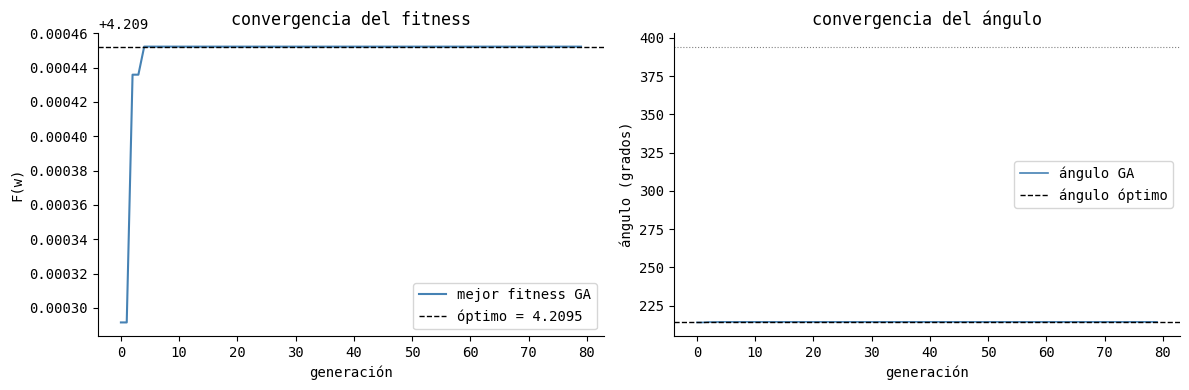

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_fit, lw=1.5, color="steelblue", label="mejor fitness GA")
axes[0].axhline(vals[0], color="k", lw=1, ls="--", label=f"óptimo = {vals[0]:.4f}")
axes[0].set_xlabel("generación")
axes[0].set_ylabel("F(w)")
axes[0].set_title("convergencia del fitness")
axes[0].legend()

axes[1].plot(np.degrees(hist_phi), lw=1.2, color="steelblue", label="ángulo GA")
axes[1].axhline(np.degrees(angulo_opt), color="k", lw=1, ls="--", label="ángulo óptimo")
axes[1].axhline(np.degrees(angulo_opt)+180, color="gray", lw=0.8, ls=":")
axes[1].set_xlabel("generación")
axes[1].set_ylabel("ángulo (grados)")
axes[1].set_title("convergencia del ángulo")
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. PCA robusto L1 — donde el GA es genuinamente necesario

El PCA estándar maximiza $\|Xw\|_2^2$ (sensible a outliers).  
La versión robusta maximiza $\|Xw\|_1 = \sum_i |x_i^\top w|$, que penaliza linealmente.  
Este problema **no tiene solución analítica cerrada**.


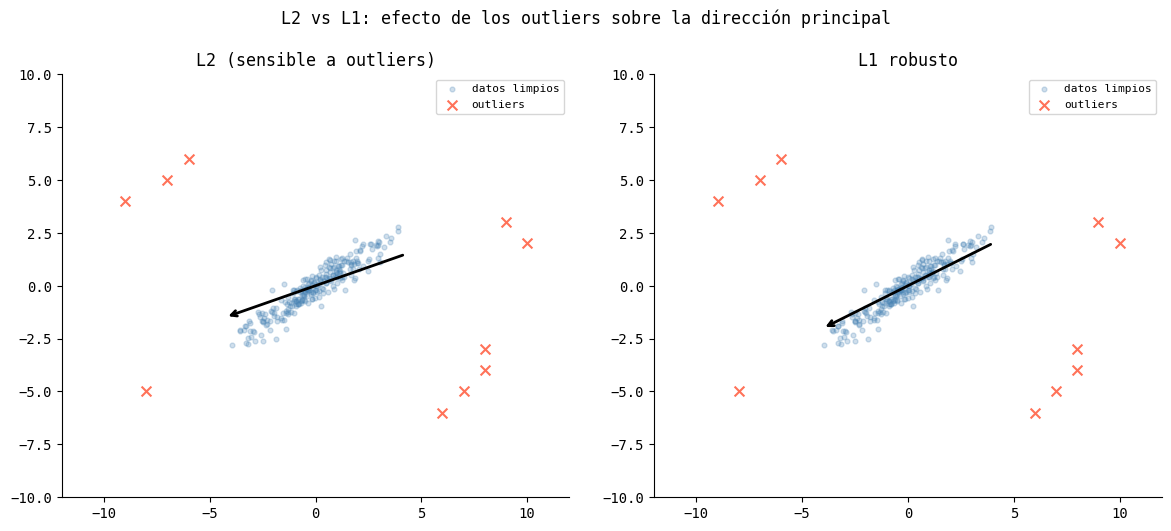

w L2 = [-0.9439 -0.3304]
w L1 = [-0.8944 -0.4472]


In [6]:
np.random.seed(7)
X_limpio = (L @ np.random.randn(p, 250)).T
outliers = np.array([[8,-4],[-7,5],[9,3],[-8,-5],[6,-6],
                     [10,2],[-9,4],[7,-5],[-6,6],[8,-3]], dtype=float)
X_out = np.vstack([X_limpio, outliers])

def fitness_l1(w, X):
    w = w / norm(w)
    return float(np.abs(X @ w).sum())

w_l2, _, _ = ga_pca(lambda w, X: fitness_l2(w, X), X_out, n_gen=120, pop_size=80, beta=3.0)
w_l1, _, _ = ga_pca(fitness_l1,                     X_out, n_gen=120, pop_size=80, beta=3.0, seed=1)

S_out = X_out.T @ X_out / (len(X_out)-1)
_, vecs_out = eigh(S_out)
w_ref = vecs_out[:, -1]
if w_l2 @ w_ref < 0: w_l2 = -w_l2
if w_l1 @ w_ref < 0: w_l1 = -w_l1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, w_plot) in zip(axes, [("L2 (sensible a outliers)", w_l2),
                                        ("L1 robusto", w_l1)]):
    ax.scatter(X_limpio[:, 0], X_limpio[:, 1], alpha=0.25, s=12,
               color="steelblue", label="datos limpios")
    ax.scatter(outliers[:, 0], outliers[:, 1], alpha=0.9, s=50,
               color="tomato", marker="x", lw=1.5, label="outliers")
    ax.annotate("", xy=w_plot*4.5, xytext=-w_plot*4.5,
                arrowprops=dict(arrowstyle="->", color="k", lw=2))
    ax.set_aspect("equal")
    ax.set_xlim(-12, 12)
    ax.set_ylim(-10, 10)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("L2 vs L1: efecto de los outliers sobre la dirección principal", y=1.02)
plt.tight_layout()
plt.show()

print(f"w L2 = {w_l2.round(4)}")
print(f"w L1 = {w_l1.round(4)}")


## 6. Conexión con cambio de medida

El GA realiza un cambio de medida en el espacio de direcciones:

$$\eta_{k+1}(dw) = \frac{e^{\beta F(w)}}{\eta_k(e^{\beta F})} \cdot (\eta_k M)(dw)$$

Al crecer $\beta$, la medida de Gibbs $\pi_\beta \propto e^{\beta w^\top S w}$ concentra toda su masa en $w^*$.


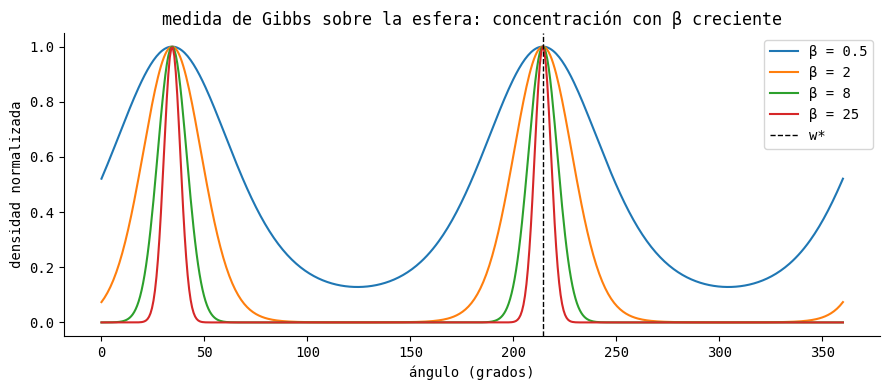

In [7]:
angulos = np.linspace(0, 2*np.pi, 500)
fs_arr = np.array([fitness_l2(np.array([np.cos(a), np.sin(a)]), S) for a in angulos])

fig, ax = plt.subplots(figsize=(9, 4))
for beta_val in [0.5, 2, 8, 25]:
    g = np.exp(beta_val * (fs_arr - fs_arr.max()))
    g /= g.max()
    ax.plot(np.degrees(angulos), g, lw=1.5, label=f"β = {beta_val}")

ax.axvline(np.degrees(angulo_opt), color="k", lw=1, ls="--", label="w*")
ax.set_xlabel("ángulo (grados)")
ax.set_ylabel("densidad normalizada")
ax.set_title("medida de Gibbs sobre la esfera: concentración con β creciente")
ax.legend()
plt.tight_layout()
plt.show()
